# SortStats-MLP — Notebook de Experimentación California Housing
Modificar únicamente la **Sección de Configuración** antes de cada corrida.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import json
import time
import random
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score, accuracy_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '.')   
from sortstats_mlp import (
    SortStatsMLPClassifier, DATASET_CONFIGS,
    build_model, build_criterion, free_gpu_memory
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memoria total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 3060 Ti
Memoria total: 8.22 GB


## Configuración de experimento
**Modificar esta celda antes de cada corrida.**

In [156]:
# Opciones: 'santander' | 'diabetes' | 'forest_cover_small' |'california' | 'adult' | 'electricity' |'miniboone' | 'covertype_full'
DATASET_NAME = 'california'

# Ruta al archivo CSV del dataset
DATA_PATH    = 'datasets/california_housing.csv'

# Columna target y columna ID (si existe; None si no hay ID)
TARGET_COL   = 'target'
ID_COL       = None

# Para datasets multiclase: si las etiquetas empiezan en 1
# Cambiar a False si las etiquetas ya son 0-indexadas.
SUBTRACT_ONE_FROM_LABELS = False

# Variante de SortStats-MLP a evaluar:
# None o [] - MLP estandar
# [0]       - SortStats en la entrada
# [1]       - SortStats en la primera capa oculta
# [2]       - SortStats en la segunda capa oculta
#Se pueden combinar capas
APPLY_SORTSTATS_AT = [0,1,2]

# Semilla
SEED = 62

# Hiperparametros de entrenamiento
EPOCHS        = 300     
ES_PATIENCE   = 30      # epocas sin mejora antes de detener
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
TEST_SIZE     = 0.2

# Steepness de la relajacion del sort 
STEEPNESS = 5.0

# Bloque del plan al que corresponde esta corrida
# Opciones: 'bloque1' | 'bloque2_ablacion' | 'bloque3_sensibilidad' | 'bloque4_robustez'
EXPERIMENT_BLOCK = 'bloque1'

# Descripcion libre de esta corrida, se guarda en el registro
EXPERIMENT_NOTE = 'California Housing SortStats capa 0, 1 y 2, Semilla 62'

# Directorio donde se guardan los registros de resultados
RESULTS_DIR = Path('resultados')
RESULTS_DIR.mkdir(exist_ok=True)

print(f'Dataset      : {DATASET_NAME}')
print(f'SortStats at : {APPLY_SORTSTATS_AT}')
print(f'Semilla      : {SEED}')
print(f'Bloque       : {EXPERIMENT_BLOCK}')

Dataset      : california
SortStats at : [0, 1, 2]
Semilla      : 62
Bloque       : bloque1


In [111]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f'Semilla fijada: {SEED}')

Semilla fijada: 62


## Carga y preprocesamiento

In [112]:
df = pd.read_csv(DATA_PATH)
print(f'Shape original: {df.shape}')

# Separar features y target
drop_cols = [TARGET_COL] + ([ID_COL] if ID_COL else [])
X_np = df.drop(columns=drop_cols).values.astype(np.float32)
y_np = df[TARGET_COL].values.astype(np.int64)

if SUBTRACT_ONE_FROM_LABELS:
    y_np = y_np - 1
    print(f'Etiquetas convertidas a 0-index (se restó 1)')

NUM_CLASSES = int(y_np.max()) + 1
N_FEATURES  = X_np.shape[1]
CFG         = DATASET_CONFIGS[DATASET_NAME]

print(f'N_FEATURES  : {N_FEATURES}')
print(f'NUM_CLASSES : {NUM_CLASSES}')
print(f'Clases      : {np.bincount(y_np)}')
print(f'HIDDEN_DIMS : {CFG["hidden_dims"]}')
print(f'Batch size  : {CFG["batch_size"]}')

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X_np, y_np, test_size=TEST_SIZE, stratify=y_np, random_state=SEED
)

# Normalizacion
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}')

Shape original: (20640, 9)
N_FEATURES  : 8
NUM_CLASSES : 2
Clases      : [10315 10325]
HIDDEN_DIMS : [32, 16, 8]
Batch size  : 512
Train: (16512, 8)  |  Val: (4128, 8)


In [113]:
BATCH_SIZE = CFG['batch_size']

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          pin_memory=(device == 'cuda'), num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=(device == 'cuda'), num_workers=0)

print(f'Batches por epoca — train: {len(train_loader)}  val: {len(val_loader)}')

Batches por epoca — train: 33  val: 9


## Modelo 

In [157]:
# Libera memoria GPU de corridas anteriores
free_gpu_memory()

model = build_model(
    dataset_name       = DATASET_NAME,
    n_features         = N_FEATURES,
    num_classes        = NUM_CLASSES,
    apply_sortstats_at = APPLY_SORTSTATS_AT,
    steepness          = STEEPNESS,
).to(device)

criterion = build_criterion(num_classes=NUM_CLASSES, y_train=y_train)
if device == 'cuda' and hasattr(criterion, 'pos_weight') and criterion.pos_weight is not None:
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=criterion.pos_weight.to(device)
    )

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=4, factor=0.5
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros entrenables: {n_params:,}')
print(model)

GPU memoria reservada: 0.03 GB  asignada: 0.02 GB
Parametros entrenables: 2,193
SortStatsMLPClassifier(
  (sortstats_layers): ModuleDict(
    (0): SortStatsLayer(
      (sorter): DiffSortNet()
    )
    (1): SortStatsLayer(
      (sorter): DiffSortNet()
    )
    (2): SortStatsLayer(
      (sorter): DiffSortNet()
    )
  )
  (blocks): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=20, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
    )
    (1): Sequential(
      (0): Linear(in_features=68, out_features=16, bias=True)
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
    )
    (2): Sequential(
      (0): Linear(in_features=36, out_features=8, bias=True)
      (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, bias=

## Loop de entrenamiento

In [158]:
def prepare_targets(y_batch, num_classes):
    if num_classes == 2:
        return y_batch.float().unsqueeze(1)
    return y_batch.long()

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for X_b, y_b in loader:
        X_b = X_b.to(device)
        y_b = prepare_targets(y_b, model.num_classes).to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_b)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for X_b, y_b in loader:
        X_b = X_b.to(device)
        y_b = prepare_targets(y_b, model.num_classes).to(device)
        total_loss += criterion(model(X_b), y_b).item() * len(X_b)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_metrics(model, loader):
    """Devuelve accuracy, f1 (macro), recall (macro) y probabilidades."""
    model.eval()
    all_preds, all_probs, all_targets = [], [], []
    for X_b, y_b in loader:
        X_b = X_b.to(device)
        all_preds.append(model.predict(X_b).cpu().numpy())
        all_probs.append(model.predict_proba(X_b).cpu().numpy())
        all_targets.append(y_b.numpy())
    preds   = np.concatenate(all_preds)
    probs   = np.concatenate(all_probs)
    targets = np.concatenate(all_targets)
    acc     = accuracy_score(targets, preds)
    f1      = f1_score(targets, preds, average='macro', zero_division=0)
    rec     = recall_score(targets, preds, average='macro', zero_division=0)
    return acc, f1, rec, probs, targets

In [159]:
history = {k: [] for k in [
    'train_loss', 'val_loss', 'val_acc', 'val_f1', 'val_recall',
    'epoch_time'
]}

best_val_f1    = -1.0
best_epoch     = 0
best_model_wts = None
no_improve     = 0

print(f'Entrenando hasta {EPOCHS} epocas (early stopping patience={ES_PATIENCE})...')
print(f'{"Epoch":>5}  {"tr_loss":>8}  {"vl_loss":>8}  {"vl_acc":>7}  '
      f'{"vl_f1":>7}  {"vl_rec":>7}  {"t(s)":>6}')

t_total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    vl_loss = evaluate_loss(model, val_loader, criterion)
    vl_acc, vl_f1, vl_rec, _, _ = evaluate_metrics(model, val_loader)
    ep_time = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)
    history['val_recall'].append(vl_rec)
    history['epoch_time'].append(ep_time)

    scheduler.step(vl_loss)

    # Early stopping sobre val_f1
    if vl_f1 > best_val_f1:
        best_val_f1    = vl_f1
        best_epoch     = epoch
        best_model_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve     = 0
    else:
        no_improve += 1

    print(f'{epoch:>5}  {tr_loss:>8.4f}  {vl_loss:>8.4f}  {vl_acc:>7.4f}  '
          f'{vl_f1:>7.4f}  {vl_rec:>7.4f}  {ep_time:>6.1f}')

    if no_improve >= ES_PATIENCE:
        print(f'\nEarly stopping en epoca {epoch} '
              f'(mejor: epoca {best_epoch}, val_f1={best_val_f1:.4f})')
        break

t_total = time.time() - t_total_start
print(f'\nTiempo total: {t_total/60:.1f} min  |  Mejor epoca: {best_epoch}  |  '
      f'Mejor val_f1: {best_val_f1:.4f}')

# Restaurar los pesos del mejor modelo
model.load_state_dict(best_model_wts)
model.to(device)
print('Pesos del mejor modelo restaurados.')

Entrenando hasta 300 epocas (early stopping patience=30)...
Epoch   tr_loss   vl_loss   vl_acc    vl_f1   vl_rec    t(s)
    1    0.6462    0.6088   0.7364   0.7272   0.7365     1.7
    2    0.5690    0.5066   0.7725   0.7705   0.7726     1.6
    3    0.5157    0.4612   0.8038   0.8034   0.8038     1.6
    4    0.4730    0.4387   0.8074   0.8061   0.8075     1.6
    5    0.4465    0.4171   0.8178   0.8168   0.8179     1.6
    6    0.4220    0.3904   0.8341   0.8336   0.8341     1.6
    7    0.4102    0.3898   0.8353   0.8347   0.8353     1.6
    8    0.3957    0.3763   0.8355   0.8345   0.8356     1.6
    9    0.3916    0.3834   0.8302   0.8295   0.8302     1.6
   10    0.3829    0.3800   0.8343   0.8337   0.8343     1.5
   11    0.3774    0.3676   0.8345   0.8330   0.8346     1.5
   12    0.3706    0.3694   0.8333   0.8326   0.8334     1.6
   13    0.3674    0.3573   0.8433   0.8425   0.8433     1.5
   14    0.3651    0.3796   0.8239   0.8216   0.8239     1.6
   15    0.3656    0.3626

## Curvas de entrenamiento

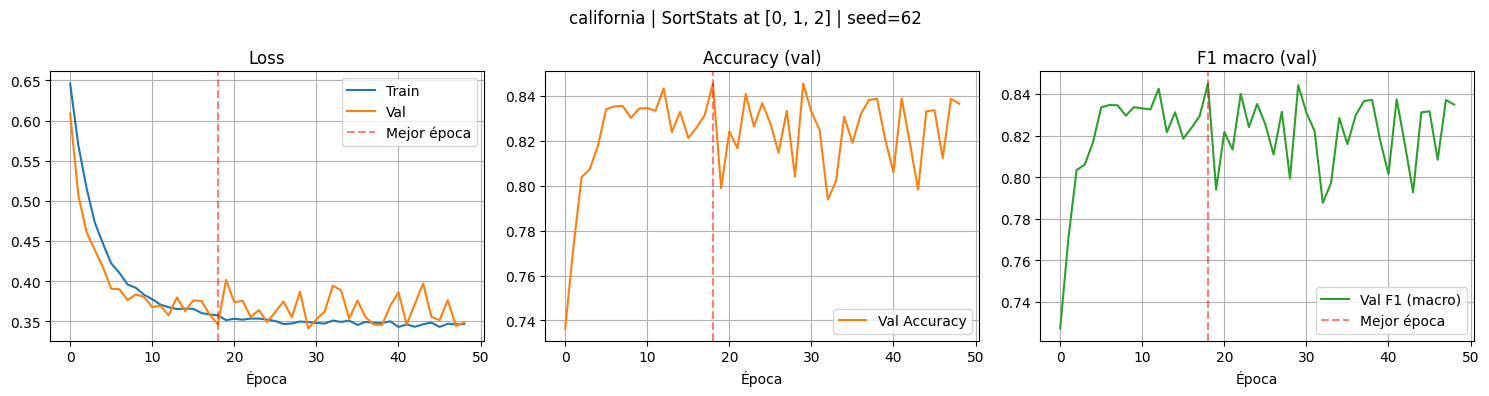

In [160]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label='Mejor época')
axes[0].set_title('Loss')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['val_acc'], label='Val Accuracy', color='tab:orange')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Accuracy (val)')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history['val_f1'], label='Val F1 (macro)', color='tab:green')
axes[2].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label='Mejor época')
axes[2].set_title('F1 macro (val)')
axes[2].set_xlabel('Época')
axes[2].legend()
axes[2].grid(True)

plt.suptitle(f'{DATASET_NAME} | SortStats at {APPLY_SORTSTATS_AT} | seed={SEED}')
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'curvas_{DATASET_NAME}_at{APPLY_SORTSTATS_AT}_s{SEED}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Evaluación final

              precision    recall  f1-score   support

           0       0.81      0.90      0.85      2063
           1       0.89      0.79      0.84      2065

    accuracy                           0.85      4128
   macro avg       0.85      0.85      0.84      4128
weighted avg       0.85      0.85      0.84      4128

Accuracy : 0.8454
F1 macro : 0.8450
Recall   : 0.8455


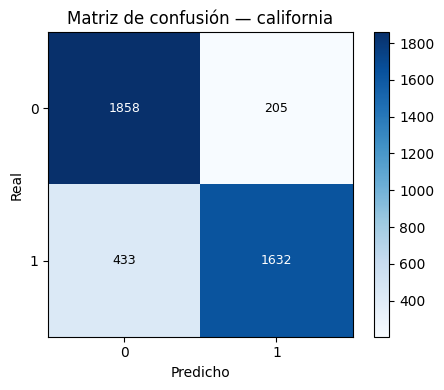

In [161]:
vl_acc, vl_f1, vl_rec, y_prob, y_true = evaluate_metrics(model, val_loader)
y_pred = np.concatenate([
    model.predict(X_b.to(device)).cpu().numpy()
    for X_b, _ in val_loader
])

print(classification_report(y_true, y_pred, zero_division=0))
print(f'Accuracy : {vl_acc:.4f}')
print(f'F1 macro : {vl_f1:.4f}')
print(f'Recall   : {vl_rec:.4f}')

# Matriz de confusion
cm       = confusion_matrix(y_true, y_pred)
n_cls    = cm.shape[0]
fig_sz   = max(5, n_cls)
fig, ax  = plt.subplots(figsize=(fig_sz, fig_sz - 1))
im       = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusión — {DATASET_NAME}')
ax.set_xticks(range(n_cls))
ax.set_yticks(range(n_cls))
fsize = 9 if n_cls <= 4 else 7
for (i, j), val in np.ndenumerate(cm):
    color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
    ax.text(j, i, f'{val}', ha='center', va='center', fontsize=fsize, color=color)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'cm_{DATASET_NAME}_at{APPLY_SORTSTATS_AT}_s{SEED}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Random Forest y XGBoost


In [119]:
if EXPERIMENT_BLOCK == 'bloque1':
    print('Entrenando modelos base...')
    results_base = {}

    # Random Forest
    t0 = time.time()
    rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_preds = rf.predict(X_val)
    rf_time  = time.time() - t0
    results_base['random_forest'] = {
        'accuracy': accuracy_score(y_val, rf_preds),
        'f1_macro': f1_score(y_val, rf_preds, average='macro', zero_division=0),
        'recall'  : recall_score(y_val, rf_preds, average='macro', zero_division=0),
        'time_s'  : rf_time,
    }
    print(f'RF  — acc: {results_base["random_forest"]["accuracy"]:.4f}  '
          f'f1: {results_base["random_forest"]["f1_macro"]:.4f}  '
          f't: {rf_time:.1f}s')

    # XGBoost
    t0 = time.time()
    xgb_objective = 'binary:logistic' if NUM_CLASSES == 2 else 'multi:softmax'
    xgb = XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        objective=xgb_objective,
        num_class=NUM_CLASSES if NUM_CLASSES > 2 else None,
        random_state=SEED, n_jobs=-1, verbosity=0,
        eval_metric='logloss',
    )
    xgb.fit(X_train, y_train)
    xgb_preds = xgb.predict(X_val)
    xgb_time  = time.time() - t0
    results_base['xgboost'] = {
        'accuracy': accuracy_score(y_val, xgb_preds),
        'f1_macro': f1_score(y_val, xgb_preds, average='macro', zero_division=0),
        'recall'  : recall_score(y_val, xgb_preds, average='macro', zero_division=0),
        'time_s'  : xgb_time,
    }
    print(f'XGB — acc: {results_base["xgboost"]["accuracy"]:.4f}  '
          f'f1: {results_base["xgboost"]["f1_macro"]:.4f}  '
          f't: {xgb_time:.1f}s')
else:
    results_base = {}
    print('Bloque != bloque1: se omiten modelos base.')

Entrenando modelos base...
RF  — acc: 0.9079  f1: 0.9079  t: 0.5s
XGB — acc: 0.9167  f1: 0.9167  t: 0.2s


## Registro de resultados

In [162]:
record = {
    # Identificacion
    'dataset'            : DATASET_NAME,
    'experiment_block'   : EXPERIMENT_BLOCK,
    'experiment_note'    : EXPERIMENT_NOTE,
    'apply_sortstats_at' : APPLY_SORTSTATS_AT,
    'seed'               : SEED,
    'steepness'          : STEEPNESS,
    # Arquitectura
    'hidden_dims'        : CFG['hidden_dims'],
    'batch_size'         : BATCH_SIZE,
    'lr'                 : LR,
    'weight_decay'       : WEIGHT_DECAY,
    'n_params'           : sum(p.numel() for p in model.parameters() if p.requires_grad),
    # Resultados del mejor punto de validacion
    'best_epoch'         : best_epoch,
    'best_val_f1'        : round(best_val_f1, 6),
    'final_val_acc'      : round(vl_acc, 6),
    'final_val_f1'       : round(vl_f1, 6),
    'final_val_recall'   : round(vl_rec, 6),
    # Tiempo
    'total_time_min'     : round(t_total / 60, 2),
    'mean_epoch_time_s'  : round(float(np.mean(history['epoch_time'])), 2),
    'epochs_trained'     : len(history['train_loss']),
    # Modelos base (solo bloque 1)
    'baselines'          : results_base,
}

record_path = RESULTS_DIR / f'record_{DATASET_NAME}_at{APPLY_SORTSTATS_AT}_s{SEED}.json'
with open(record_path, 'w') as f:
    json.dump(record, f, indent=2)

print(f'Registro guardado: {record_path}')
print(json.dumps({k: v for k, v in record.items() if k != 'baselines'}, indent=2))

Registro guardado: resultados/record_california_at[0, 1, 2]_s62.json
{
  "dataset": "california",
  "experiment_block": "bloque1",
  "experiment_note": "California Housing SortStats capa 0, 1 y 2, Semilla 62",
  "apply_sortstats_at": [
    0,
    1,
    2
  ],
  "seed": 62,
  "steepness": 5.0,
  "hidden_dims": [
    32,
    16,
    8
  ],
  "batch_size": 512,
  "lr": 0.001,
  "weight_decay": 0.0001,
  "n_params": 2193,
  "best_epoch": 19,
  "best_val_f1": 0.844981,
  "final_val_acc": 0.845446,
  "final_val_f1": 0.844981,
  "final_val_recall": 0.845472,
  "total_time_min": 1.27,
  "mean_epoch_time_s": 1.55,
  "epochs_trained": 49
}
